In [ ]:
import bigframes.pandas as bf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
!pip install pyfonts
from pyfonts import load_google_font

# Load the DM Sans font (Google Font)
font = load_google_font("DM Sans")
font.set_size(11)

bf.options.bigquery.location = "EU" #this variable is set based on the dataset you chose to query
bf.options.bigquery.project = "macro-dreamer-406710" #this variable is set based on the dataset you chose to query

df = bf.read_gbq('macro-dreamer-406710.wrp_raw.wrp_23_raw').to_pandas()

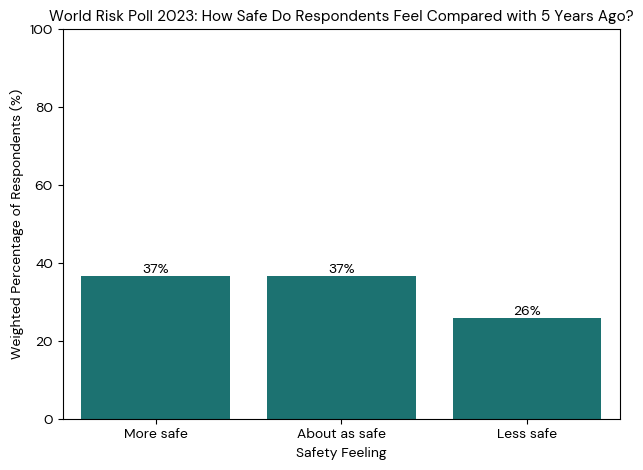

In [ ]:
# FIGURE 1 (WEIGHTED)

# ensure weights are numeric
df['PROJWT'] = pd.to_numeric(df['PROJWT'], errors='coerce')

# drop missing fields
df = df.dropna(subset=['WP20711', 'PROJWT'])

# compute weighted percentages
weighted_percent = (
    df
    .groupby('WP20711')['PROJWT']
    .sum()
    .pipe(lambda x: x / x.sum() * 100)
    .reset_index(name='proportion')
)

# define invalid responses
fixed_categories = ['(DK)', '(Refused)']

# select top 3 valid categories by weighted proportion (percentages are still from full dataset)
top3_df = (
    weighted_percent
    .loc[~weighted_percent['WP20711'].isin(fixed_categories)]
    .sort_values('proportion', ascending=False)
    .head(3)
)

# preserve order for plotting
custom_order = top3_df['WP20711'].tolist()

# Plot bar chart

ax = sns.barplot(
    data=top3_df,
    x='WP20711',  # category axis
    y='proportion',         # percentage axis
    color='#0d817f',
    order=custom_order
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container,
                 labels=[f"{bar.get_height():.0f}%" for bar in container],
                 fontproperties=font,
                 fontsize=10)

# Apply DM Sans to tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)
    label.set_fontsize(10)  # Change 10 to your desired size

# Style
plt.ylabel('Weighted Percentage of Respondents (%)', fontproperties=font, size=10)
plt.xlabel('Safety Feeling', fontproperties=font, size=10)
plt.title('World Risk Poll 2023: How Safe Do Respondents Feel Compared with 5 Years Ago?', fontproperties=font)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [ ]:
#creating an encoded version of the responses to greatest risk to daily safety question
df['safety_risk_numeric'] = df['WP22331'].map({'TRANSPORTATION: Road-related accidents/injuries (such as using a bicycle, car, motorbike, truck, van, bus,': 1,
                                               'TRANSPORTATION: Other transportation-related accidents/injuries (such as subway, train, plane, boat, etc.)': 2,
                                               'CRIME/VIOLENCE (including domestic violence, violence outside the home, and other crimes)': 3,
                                               'WAR/TERRORISM': 4,
                                               'HEALTH: personal health condition/illness': 5,
                                               'HEALTH: drugs, alcohol, smoking': 6,
                                               'HEALTH: COVID-19/Coronavirus related': 7,
                                               'HEALTH: Mental stress/exhaustion/falling/tripping': 8,
                                               'FINANCIAL: not having enough money to pay for the things you need': 9,
                                               'ECONOMY: Economy-related, such as unemployment, losing your job, high prices': 10,
                                               'POLITICS: Politics/political situation/corruption': 11,
                                               'TECHNOLOGY: Internet/technology related risks': 12,
                                               'WATER: Water supply or drinking unclean water': 13,
                                               'FOOD-RELATED: eating unsafe or contaminated\xa0food': 14,
                                               'FOOD-RELATED: insufficient or lack of food (hunger), not enough money for food': 15,
                                               'COOKING or other household accidents/injuries': 16,
                                               'WORK: Work-related accidents: physical injuries': 17,
                                               'ENVIRONMENT: Pollution': 18,
                                               'ENVIRONMENT: Climate change or severe weather-related events, such as floods, drought, wildfires, etc.': 19,
                                               'ENVIRONMENT: Non-weather-related disasters, such as earthquakes or volcanoes': 20,
                                               'DROWNING': 21,
                                               'Other': 22,
                                               'Nothing/No risks': 23,
                                               'Don’t know': 98,
                                               'Refused': 99})
df['safety_risk_numeric']

,safety_risk_numeric
0,1
1,9
2,5
3,3
4,1
...,...
146905,22
146906,9
146907,10
146908,4


In [ ]:
# creating a graph-appropriate version of the safety risk question
df['safety_risk_graph'] = df['safety_risk_numeric'].map({
    1: 'Road Accidents',
    2: 'Non-Road Transport Accidents',
    3: 'Crime & Violence',
    4: 'War & Terrorism',
    5: 'Health Issues',
    6: 'Substance Use',
    7: 'COVID-19',
    8: 'Mental Stress',
    9: 'Finances',
    10: 'The Economy',
    11: 'Politics',
    12: 'Technology and The Internet',
    13: 'Water Contamination',
    14: 'Food Contamination',
    15: 'Food Insecurity',
    16: 'Household Injury',
    17: 'Workplace Injury',
    18: 'Pollution',
    19: 'Extreme Weather',
    20: 'Earthquakes and Tornadoes',
    21: 'Drowning',
    22: 'Other',
    23: 'No risks',
    98: 'Don’t know',
    99: 'Refused'

})

# only respondents that answered that they felt less safe & that they do not trust their government
full_lesssafe_notrust_df = df[
    (df['WP20711'] == 'Less safe') &
    (df['WP139'] == 'No')
]

In [ ]:
filtered_df = df.copy()

filtered_df = filtered_df[
    ~filtered_df['safety_risk_numeric'].isin([98, 23, 22, 99])
]

filtered_df = filtered_df[
    ~filtered_df['WP139'].isin(['(DK)', '(Refused)', np.nan, ' ', ''])
]

filtered_df = filtered_df[
    ~filtered_df['WP20711'].isin(['(DK)', '(Refused)', np.nan, ' ', ''])
]

/tmp/ipykernel_51049/2241848198.py:24: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sns.barplot(


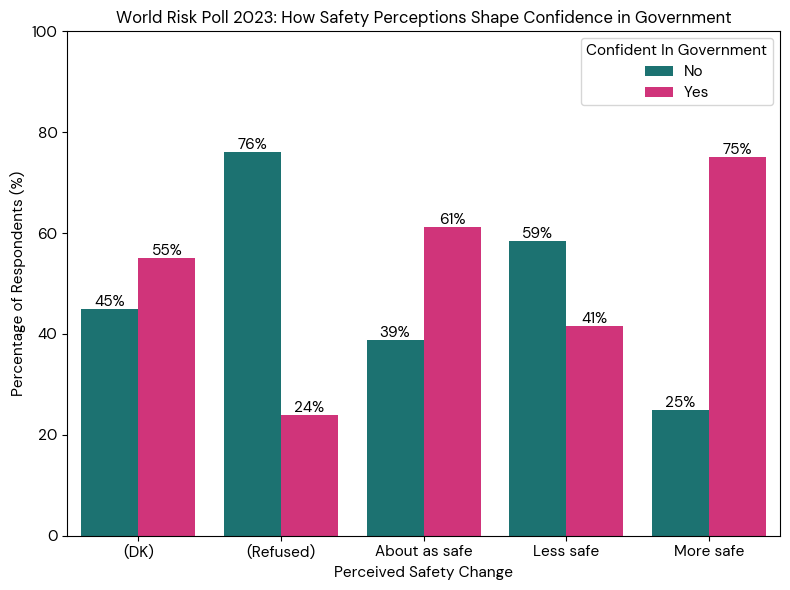

In [ ]:
#FIGURE 2 (WEIGHTED)
#WP139: do you feel confident in your national government (yes or no) (asked in gallup world poll)
#WP20711: how safe do you feel compared with five years ago? (more, less, as safe) (asked in the foundation's world risk poll)

# Step 1: Group and calculate weighted proportions
filtered_df = df[~df['safety_risk_numeric'].isin([98, 23, 22, 99])]
filtered_df = filtered_df[~filtered_df['WP139'].isin(['(DK)', '(Refused)', np.nan, ' ', ''])] #cleaning confidence in government column
proportion_df = (
    filtered_df
    .groupby(['WP20711', 'WP139'], as_index=False)
    .agg(count=('PROJWT', 'sum'))   # weighted count = sum of weights
)

# Convert to percentage (0–100) within each WP20711 using weighted counts
proportion_df['proportion'] = (
    proportion_df
    .groupby('WP20711')['count']
    .transform(lambda x: (x / x.sum()) * 100)
)

# Step 2: Create the bar plot
plt.figure(figsize=(8, 6))
colors=['#0d817f','#ea1a78', '#c1c3c3', '#3f647d']
ax = sns.barplot(
    data=proportion_df,
    x='WP20711',
    y='proportion',
    hue='WP139',
    palette=colors
)

# Step 3: Add percentage annotations (already in % now)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{bar.get_height():.0f}%" for bar in container],
        fontproperties=font
    )

# Apply DM Sans to tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)

# Step 4: Final plot settings
plt.ylabel('Percentage of Respondents (%)', fontproperties=font)
plt.xlabel('Perceived Safety Change', fontproperties=font)
plt.title('World Risk Poll 2023: How Safety Perceptions Shape Confidence in Government', fontproperties=font, size=12)
plt.ylim(0, 100)
plt.legend(title='Confident In Government')

# Apply DM Sans to legend text
legend = ax.get_legend()
for text in legend.get_texts():
    text.set_fontproperties(font)
legend.get_title().set_fontproperties(font)

plt.tight_layout()
plt.show()

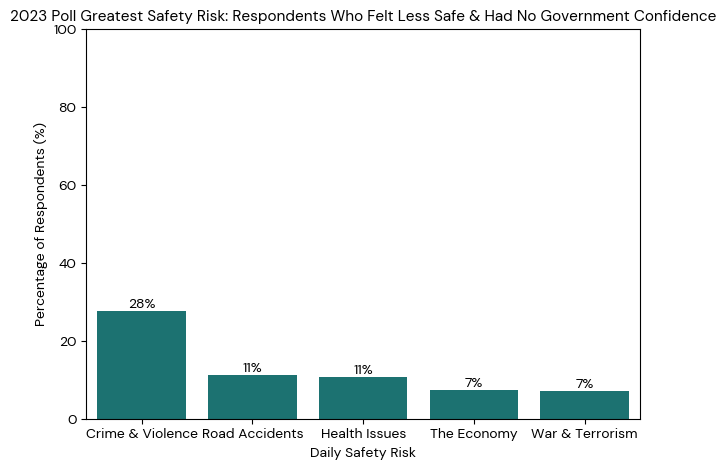

In [ ]:
# WHAT IS THE GREATEST SAFETY RISK FOR THOSE WHO ARE NOT CONFIDENT IN GOVERNMENT AND FELT LESS SAFE?

# Count and percentage
proportion2_df = (
    full_lesssafe_notrust_df['safety_risk_graph']
    .value_counts(normalize=True) * 100
).reset_index()

proportion2_df.columns = ['safety_risk_graph', 'proportion']

# Define invalid responses
fixed_categories = ['Don’t know', 'No risks', 'Refused', 'Other']

# Keep full data proportions, but only *display* top 5 valid categories
valid_df = proportion2_df[~proportion2_df['safety_risk_graph'].isin(fixed_categories)]

# Get top 5 valid categories (percentages are still from full dataset)
top5_df = valid_df.head(5)

# Keep the same proportions as computed earlier
custom_order = top5_df['safety_risk_graph'].tolist()

# Plot horizontal bar chart
ax = sns.barplot(
    data=top5_df,
    x='safety_risk_graph',  # category axis
    y='proportion',         # percentage axis
    color='#0d817f',
    order=custom_order
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, labels=[f"{bar.get_height():.0f}%" for bar in container], fontsize=10, fontproperties=font)

# Apply DM Sans to tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)
    label.set_fontsize(10)

# Style
plt.ylabel('Percentage of Respondents (%)', fontproperties=font, fontsize=10)
plt.xlabel('Daily Safety Risk', fontproperties=font, fontsize=10 )
plt.title('2023 Poll Greatest Safety Risk: Respondents Who Felt Less Safe & Had No Government Confidence', fontsize=11, fontproperties=font)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

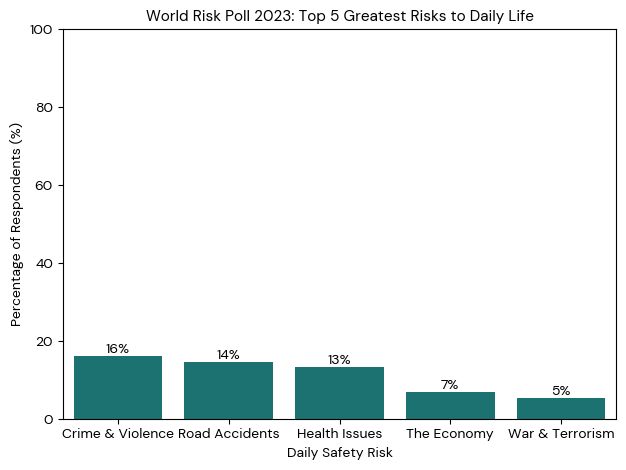

In [ ]:
#creating the same chart but for the wider population (i want to change this to be everyone excluding the conditions of less safe df)

# Count and percentage
proportion3_df = (
    df['safety_risk_graph']
    .value_counts(normalize=True) * 100 # by default, value_counts sorts the values in descending order
).reset_index()

proportion3_df.columns = ['safety_risk_graph', 'proportion']

# Define invalid responses
fixed_categories = ['Don’t know', 'No risks', 'Refused', 'Other']

# Keep full data proportions, but only *display* top 5 valid categories
valid_df = proportion3_df[~proportion3_df['safety_risk_graph'].isin(fixed_categories)]

# Get top 5 valid categories (percentages are still from full dataset)
top5_df = valid_df.head(5)

# Keep the same proportions as computed earlier
custom_order = top5_df['safety_risk_graph'].tolist()


# Plot horizontal bar chart

ax = sns.barplot(
    data=top5_df,
    x='safety_risk_graph',  # category axis
    y='proportion',         # percentage axis
    color='#0d817f',
    order=custom_order
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container,
                 labels=[f"{bar.get_height():.0f}%" for bar in container],
                 fontproperties=font,
                 fontsize=10)

# Apply DM Sans to tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)
    label.set_fontsize(10)  # Change 10 to your desired size

# Style
plt.ylabel('Percentage of Respondents (%)', fontproperties=font, size=10)
plt.xlabel('Daily Safety Risk', fontproperties=font, size=10)
plt.title('World Risk Poll 2023: Top 5 Greatest Risks to Daily Life', fontproperties=font)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

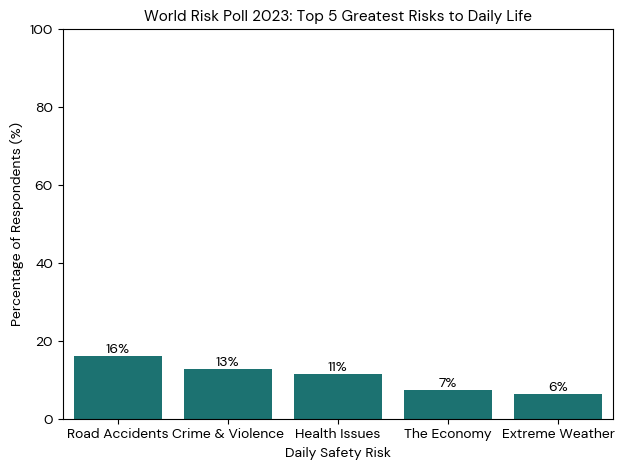

In [ ]:
#creating the same chart but for the wider population

# WEIGHTED VERSION OF ABOVE CHART

# ensure weights are numeric
df['PROJWT'] = pd.to_numeric(df['PROJWT'], errors='coerce')

# drop missing fields
df = df.dropna(subset=['safety_risk_graph', 'PROJWT'])

# compute weighted percentages
weighted_percent = (
    df
    .groupby('safety_risk_graph')['PROJWT']
    .sum()
    .pipe(lambda x: x / x.sum() * 100)
    .reset_index(name='proportion')
)

# define invalid responses
fixed_categories = ['Don’t know', 'No risks', 'Refused', 'Other']

# select top 5 valid categories by weighted proportion
top5_df = (
    weighted_percent
    .loc[~weighted_percent['safety_risk_graph'].isin(fixed_categories)]
    .sort_values('proportion', ascending=False)
    .head(5)
)

# preserve order for plotting
custom_order = top5_df['safety_risk_graph'].tolist()

# plot
ax = sns.barplot(
    data=top5_df,
    x='safety_risk_graph',
    y='proportion',
    color='#0d817f',
    order=custom_order
)

# add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{bar.get_height():.0f}%" for bar in container],
        fontproperties=font,
        fontsize=10
    )

# styling
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)
    label.set_fontsize(10)

plt.ylabel('Percentage of Respondents (%)', fontproperties=font, size=10)
plt.xlabel('Daily Safety Risk', fontproperties=font, size=10)
plt.title('World Risk Poll 2023: Top 5 Greatest Risks to Daily Life', fontproperties=font)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


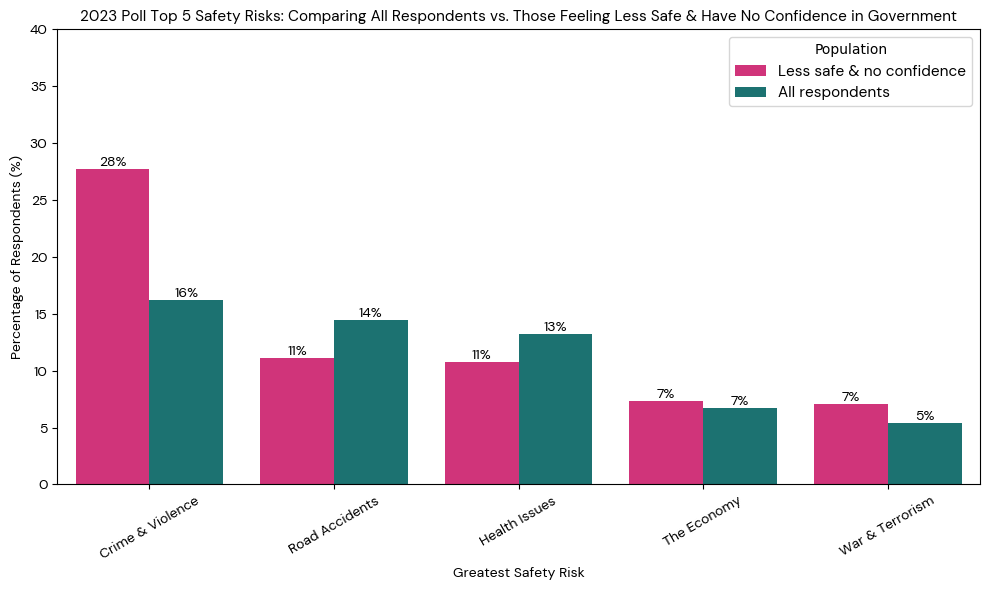

In [ ]:
# CREATING A GRAPH THAT WILL COMBINE THE TWO

fixed_categories = ['Don’t know', 'No risks', 'Refused', 'Other']

# 1. Keep full dataset percentages as they are, but pick top 5 valid from proportion2_df
valid_p2 = proportion2_df[~proportion2_df['safety_risk_graph'].isin(fixed_categories)]
top5_list = valid_p2['safety_risk_graph'].head(5).tolist()  # list of the 5 categories to show

# 2. Filter both proportion dataframes to those top 5 categories
p2_top5 = proportion2_df[proportion2_df['safety_risk_graph'].isin(top5_list)].copy()
p3_top5 = proportion3_df[proportion3_df['safety_risk_graph'].isin(top5_list)].copy()

# 3. Ensure both frames contain all top5 categories (if any missing, add with 0)
def ensure_all_categories(df, categories):
    missing = [c for c in categories if c not in df['safety_risk_graph'].values]
    if missing:
        filler = pd.DataFrame({
            'safety_risk_graph': missing,
            'proportion': [0.0] * len(missing)
        })
        df = pd.concat([df, filler], ignore_index=True)
    # keep the categories in the given order
    df['safety_risk_graph'] = pd.Categorical(df['safety_risk_graph'], categories=categories, ordered=True)
    return df

p2_top5 = ensure_all_categories(p2_top5, top5_list)
p3_top5 = ensure_all_categories(p3_top5, top5_list)

# 4. Add a 'group' column then combine
p2_top5['group'] = 'Less safe & no confidence'
p3_top5['group'] = 'All respondents'

combined = pd.concat([p2_top5, p3_top5], ignore_index=True)

# 5. Plot grouped bar chart (side-by-side bars for each category) ---
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=combined,
    x='safety_risk_graph',
    y='proportion',
    hue='group',
    order=top5_list,
    dodge=True,      # ensures bars are side-by-side
    palette=['#ea1a78', '#0d817f'] # lr foundation colors
)

#Adding labels for each bar
for container in ax.containers:
    labels = [f"{v.get_height():.0f}%" for v in container]
    try:
        ax.bar_label(container, labels=labels, fontsize=10, fontproperties=font)
    except Exception:
        ax.bar_label(container, labels=labels, fontsize=10)

#Styling
ax.set_ylabel('Percentage of Respondents (%)', fontproperties=font, fontsize=10)
ax.set_xlabel('Greatest Safety Risk', fontproperties=font, fontsize=10)
ax.set_title('2023 Poll Top 5 Safety Risks: Comparing All Respondents vs. Those Feeling Less Safe & Have No Confidence in Government', fontproperties=font, fontsize=11)
ax.set_ylim(0, 40)
plt.xticks(rotation=30, fontproperties=font, fontsize=10)
plt.yticks(fontproperties=font, fontsize=10)
plt.legend(title='Population', loc='upper right', prop=font, fontsize=10)
plt.tight_layout()
plt.show()


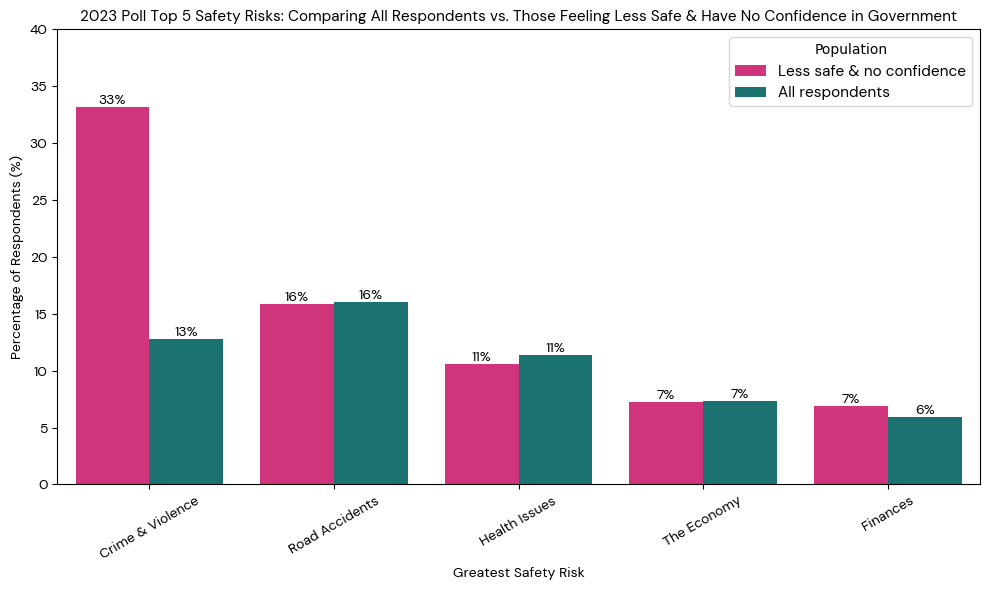

In [ ]:
# FIGURE 3: GREATEST PERCEIVED PERSONAL SAFETY RISKS GLOBALLY

weight_col = 'PROJWT'

fixed_categories = ['Don’t know', 'No risks', 'Refused', 'Other']

# only respondents that answered that they felt less safe & that they do not trust their government
lesssafe_notrust_df = filtered_df[
    (filtered_df['WP20711'] == 'Less safe') &
    (filtered_df['WP139'] == 'No')
]

proportion2_df = (
    lesssafe_notrust_df
    .dropna(subset=['safety_risk_graph', weight_col])
    .groupby('safety_risk_graph', as_index=False)
    .agg(count=(weight_col, 'sum'))  # weighted count
)
proportion2_df['proportion'] = proportion2_df['count'] / proportion2_df['count'].sum() * 100
proportion2_df = proportion2_df.sort_values('proportion', ascending=False).reset_index(drop=True)

proportion3_df = (
    df
    .dropna(subset=['safety_risk_graph', weight_col])
    .groupby('safety_risk_graph', as_index=False)
    .agg(count=(weight_col, 'sum'))  # weighted count
)
proportion3_df['proportion'] = proportion3_df['count'] / proportion3_df['count'].sum() * 100
proportion3_df = proportion3_df.sort_values('proportion', ascending=False).reset_index(drop=True)

# 1. Keep full dataset percentages as they are, but pick top 5 valid from proportion2_df
valid_p2 = proportion2_df[~proportion2_df['safety_risk_graph'].isin(fixed_categories)]
top5_list = valid_p2['safety_risk_graph'].head(5).tolist()  # list of the 5 categories to show

# 2. Filter both proportion dataframes to those top 5 categories
p2_top5 = proportion2_df[proportion2_df['safety_risk_graph'].isin(top5_list)].copy()
p3_top5 = proportion3_df[proportion3_df['safety_risk_graph'].isin(top5_list)].copy()

# 3. Ensure both frames contain all top5 categories (if any missing, add with 0)
def ensure_all_categories(df, categories):
    missing = [c for c in categories if c not in df['safety_risk_graph'].values]
    if missing:
        filler = pd.DataFrame({
            'safety_risk_graph': missing,
            'proportion': [0.0] * len(missing)
        })
        df = pd.concat([df, filler], ignore_index=True)
    # keep the categories in the given order
    df['safety_risk_graph'] = pd.Categorical(df['safety_risk_graph'], categories=categories, ordered=True)
    return df

p2_top5 = ensure_all_categories(p2_top5, top5_list)
p3_top5 = ensure_all_categories(p3_top5, top5_list)

# 4. Add a 'group' column then combine
p2_top5['group'] = 'Less safe & no confidence'
p3_top5['group'] = 'All respondents'

combined = pd.concat([p2_top5, p3_top5], ignore_index=True)

# 5. Plot grouped bar chart (side-by-side bars for each category) ---
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=combined,
    x='safety_risk_graph',
    y='proportion',
    hue='group',
    order=top5_list,
    dodge=True,      # ensures bars are side-by-side
    palette=['#ea1a78', '#0d817f'] # lr foundation colors
)

#Adding labels for each bar
for container in ax.containers:
    labels = [f"{v.get_height():.0f}%" for v in container]
    try:
        ax.bar_label(container, labels=labels, fontsize=10, fontproperties=font)
    except Exception:
        ax.bar_label(container, labels=labels, fontsize=10)

#Styling
ax.set_ylabel('Percentage of Respondents (%)', fontproperties=font, fontsize=10)
ax.set_xlabel('Greatest Safety Risk', fontproperties=font, fontsize=10)
ax.set_title('2023 Poll Top 5 Safety Risks: Comparing All Respondents vs. Those Feeling Less Safe & Have No Confidence in Government', fontproperties=font, fontsize=11)
ax.set_ylim(0, 40)
plt.xticks(rotation=30, fontproperties=font, fontsize=10)
plt.yticks(fontproperties=font, fontsize=10)
plt.legend(title='Population', loc='upper right', prop=font, fontsize=10)
plt.tight_layout()
plt.show()


In [ ]:
# CLEANING TO PREP FOR OVERREP CHART

print(df['WP20711'].unique()) #checking the responses in the more/less safe column are valid
print(df['WP139'].unique()) #same with confidence in government response question

clean_df = df[
    (~df['WP139'].isin(['<NA>', '(DK)', '(Refused)'])) &
    (~df['WP20711'].isin(['<NA>', '(DK)', '(Refused)'])) &
    (df['WP139'].notna()) &
    (df['WP20711'].notna())
]

full_lesssafe_notrust_df = full_lesssafe_notrust_df[
    (clean_df['WP20711'] == 'Less safe') &
    (clean_df['WP139'] == 'No')
]

<ArrowStringArray>
['Less safe', 'More safe', 'About as safe', '(DK)', '(Refused)']
Length: 5, dtype: string
<ArrowStringArray>
['No', ' ', 'Yes', '(DK)', '(Refused)']
Length: 5, dtype: string


/tmp/ipykernel_51049/2049068725.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  full_lesssafe_notrust_df = full_lesssafe_notrust_df[


In [ ]:
#checking the cleanliness of the country column
print(full_lesssafe_notrust_df['WP5'].isna().any())
country_list = full_lesssafe_notrust_df['WP5'].unique().tolist()
print(country_list) #check for missspellings (none found)

False
['United States', 'Georgia', 'Costa Rica', 'Uganda', 'Venezuela', 'Finland', 'Peru', 'Spain', 'Paraguay', 'Malaysia', 'Armenia', 'Namibia', 'France', 'Belgium', 'Chile', 'Germany', 'Zambia', 'Argentina', 'Hungary', 'India', 'Ecuador', 'Colombia', 'Israel', 'Bulgaria', 'Sierra Leone', 'Brazil', 'Palestinian Territories', 'Ukraine', 'Myanmar', 'Uruguay', 'Kazakhstan', 'Botswana', 'Cameroon', 'Canada', 'Slovakia', 'Portugal', 'Mozambique', 'Malta', 'Honduras', 'Kenya', 'Dominican Republic', 'Ivory Coast', 'New Zealand', 'Benin', 'Iraq', 'Netherlands', 'Malawi', 'Australia', 'Greece', 'Chad', 'Lebanon', 'Panama', 'Nigeria', 'Jordan', 'The Gambia', 'Hong Kong', 'Poland', 'Russia', 'Tunisia', 'Mexico', 'South Africa', 'Yemen', 'Japan', 'Senegal', 'Sweden', 'Congo Brazzaville', 'Bolivia', 'Italy', 'Congo (Kinshasa)', 'South Korea', 'Kyrgyzstan', 'Mongolia', 'Albania', 'Moldova', 'Cyprus', 'Estonia', 'Iran', 'Mauritania', 'Eswatini', 'North Macedonia', 'Croatia', 'Denmark', 'Norway', 'Th

In [ ]:
# Are there any countries that are overrepresented in the group of people who feel less safe and have no confidence in their government?
# Not just interested in which countries are large in the subset — interested in understanding which ones are disproportionately represented relative to how many total respondents they had.

print(full_lesssafe_notrust_df['WP5'].nunique()) #counting the number of unique countries in the subset

# 1. Weighted Proportion of each country in the full dataset
full_country_dist = (
    clean_df.groupby('WP5')['PROJWT'].sum() / clean_df['PROJWT'].sum()
)

# 2. Weighted Proportion of each country in the filtered subset
subset_country_dist = (
    full_lesssafe_notrust_df.groupby('WP5')['PROJWT'].sum() / full_lesssafe_notrust_df['PROJWT'].sum()
)

# 3. Combine into a DataFrame
overrep_df = pd.concat([subset_country_dist, full_country_dist], axis=1)
overrep_df.columns = ['subset_proportion', 'full_proportion']

# 4. Calculate overrepresentation ratio
overrep_df['overrepresentation_ratio'] = overrep_df['subset_proportion'] / overrep_df['full_proportion']

# 5. Sort by countries that are most overrepresented
overrep_df = overrep_df.sort_values('overrepresentation_ratio', ascending=False)

print(overrep_df.head(10))  # Top 10 most overrepresented countries


124
              subset_proportion  full_proportion  overrepresentation_ratio
WP5                                                                       
Lebanon                0.003917         0.000673                  5.823541
Ecuador                0.012781         0.002309                  5.536099
Chile                  0.011072         0.002727                  4.060756
Argentina              0.023705         0.006041                  3.924233
Peru                   0.015867         0.004371                  3.630313
Israel                 0.003808         0.001145                  3.327026
Greece                 0.005365         0.001622                  3.306949
Venezuela              0.011348         0.003506                  3.237043
South Africa           0.023148          0.00717                   3.22838
The Gambia             0.000771         0.000252                  3.057247


In [ ]:
#making sure the sample sizes for the top overrepresented countries aren't too small (i.e. <30)
full_lesssafe_notrust_df['WP5'].value_counts().head(10) #ensures they aren't overrepresented due to noise

,count
WP5,
Lebanon,695
Ecuador,674
Chile,530
Argentina,494
Peru,464
Israel,394
South Africa,394
Malta,390
Venezuela,385


/tmp/ipykernel_51049/1624283007.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_51049/1624283007.py:2: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(


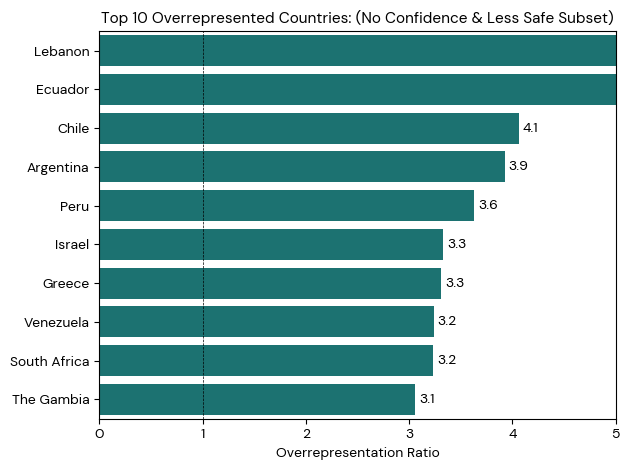

In [ ]:
# Figure 4: TOP 10 OVERREPRESENTED COUNTRIES CHART IN NO CONFIDENCE-LESS SAFE SUBSET
ax = sns.barplot(
    y='WP5',
    x='overrepresentation_ratio',
    data=overrep_df.head(10),
    orient='h',
    palette=['#0d817f']
)

# Addinng bar labels
for container in ax.containers:
    labels = [f"{v.get_width():.1f}" for v in container]  # use width for horizontal bars
    ax.bar_label(container, labels=labels, fontsize=10, fontproperties=font, padding=3)


plt.axvline(x=1, color='black', linestyle='--', linewidth=0.5)
plt.ylabel('')
plt.xlabel('Overrepresentation Ratio', fontproperties=font, fontsize=10)
plt.xticks(fontproperties=font, fontsize=10)
plt.yticks(fontproperties=font, fontsize=10)
plt.xlim(0,5)
plt.title('Top 10 Overrepresented Countries: (No Confidence & Less Safe Subset)', fontsize=11, fontproperties=font)
plt.tight_layout()
plt.show()